# Scattered-wave-function (SWF) approach for pair production by curved spacetimes

This notebook computes the probability of pair production in curved spacetimes with metrics of the "inflation" form $ds^2=dt^2-e^{A(t,x)}dx^2$ or Gullstrand-Painleve form $ds^2=dt^2-[dx-v(t,x)dt]^2$. The code allows for nontrivial holonomy, i.e. $A(-\infty,x)\ne A(+\infty,x)$.

The implementation uses JAX and is designed to run efficiently on GPUs.
The computations presented below were performed on an NVIDIA A100 GPU
using Google Colab.

The implementation is based on the methods developed in:

1. Greger Torgrimsson,\
**Momentum correlation in pair production by spacetime-dependent fields from scattered wave functions**\
Phys. Rev. D **112**, 116011 (2025)


2. Greger Torgrimsson,\
**Solving the Dirac equation on a GPU for strong-field processes in multidimensional background fields**\
arXiv:2512.16889 [hep-ph]

3. P. Semren and G. Torgrimsson,\
**Scattered wave functions and worldline instantons for particle production in curved spacetime**\
(to appear)



This notebook was used to produce the SWF results presented in [3] for a metric with nontrivial holonomy. The other SWF results were produced with jaxGRandQED.ipnb.

method1() and method2() in this notebook correspond to the two methods in the appendix of [3] for dealing with metrics with nontrivial holonomy.

**Author:** Greger Torgrimsson


# Import

diffrax contains the ODE solver for solving the Dirac equation on a GPU.

In [ ]:
# this is needed when running this code on Colab
%%capture output
%pip install -U "jax[cuda12]"

In [ ]:
# this is needed when running this code on Colab
%%capture output
%pip install diffrax

In [ ]:
import jax
import jax.numpy as np
from diffrax import diffeqsolve, ODETerm, Dopri5, Tsit5, PIDController, SaveAt

import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline, RegularGridInterpolator
from scipy.integrate import quad
from tqdm import tqdm

In [ ]:
precision=64

if precision==32:
    realType=np.float32
    compType=np.complex64

elif precision==64:
    jax.config.update("jax_enable_x64", True)
    realType=np.float64
    compType=np.complex128

In [ ]:
def toMathematica(arr):
  mathematica_str=str(arr.tolist()).replace('[','{').replace(']','}').replace("e","*10^").replace("j","I").replace("(","").replace(")","")
  print(mathematica_str)

In [ ]:
#tol=1e-7
@jax.jit
def chop(x, tol=1e-10):
    return np.where(np.abs(x) < tol, 0.0, x)

In [ ]:
@jax.jit
def simpson_jax(y, dx=1.0):
    n = y.shape[-1]
    if n % 2 == 1:
        # Odd number of samples → pure Simpson's 1/3 rule
        return (dx/3) * (
            y[..., 0]
            + 4 * np.sum(y[..., 1:-1:2], axis=-1)
            + 2 * np.sum(y[..., 2:-2:2], axis=-1)
            + y[..., -1]
        )
    else:
        # Even number of samples → use Simpson's 1/3 on first n-3, 3/8 on last 4
        y_main = y[..., :-3]
        y_tail = y[..., -4:]

        main = (dx/3) * (
            y_main[..., 0]
            + 4 * np.sum(y_main[..., 1:-1:2], axis=-1)
            + 2 * np.sum(y_main[..., 2:-2:2], axis=-1)
            + y_main[..., -1]
        )

        tail = (3*dx/8) * (
            y_tail[..., 0]
            + 3 * y_tail[..., 1]
            + 3 * y_tail[..., 2]
            + y_tail[..., 3]
        )

        return main + tail

In [ ]:
from datetime import datetime
import time
from IPython import get_ipython

start_time = time.perf_counter()

In [ ]:
def pre_run_cell(info):
    global start_time
    start_time = time.perf_counter()

def post_run_cell(result):
    end_time = time.perf_counter()
    elapsed = end_time - start_time
    print(f"{datetime.now().strftime('%Y-%m-%d %H:%M:%S')} | elapsed time: {elapsed:.3f} s")

ip = get_ipython()
ip.events.register('pre_run_cell', pre_run_cell)
ip.events.register('post_run_cell', post_run_cell)

2026-06-22 09:43:09 | elapsed time: 0.005 s


2026-06-22 09:43:09 | elapsed time: 0.008 s


In [ ]:
import sympy as sp
from jax.scipy.special import erf as jax_erf

my_modules = [
    {"erf": jax_erf},   # custom overrides
    "jax"               # then fall back to JAX backend
]

t_sym, x_sym, y_sym, z_sym = sp.symbols('t_sym x_sym y_sym z_sym', real=True)

2026-06-22 09:43:11 | elapsed time: 2.273 s


# Inflation example

The field and the scattered wave function should be contained in $-x_b<x,y,z<x_b$. $n_x$ is the number of points in the $x$, $y$ and $z$ directions. $n_k$ ($\geq n_x$) is the number of points in the Fourier space.   
$-\partial_0\psi=\left(\frac{1}{2}\partial_t A+\alpha^1 e^{-A}\partial_1+i\beta\right)\psi\qquad$
$G_0=\frac{1}{2}\partial_t A\qquad G_1=e^{-A}$

In [ ]:
xDim=1

omega = sp.Rational(2,10)
kappa = omega

ramp_down=1/(1+sp.exp(-4*(omega*t_sym-1)))
A_sym = -sp.exp(-(ramp_down)*(omega*t_sym)**2-(kappa*x_sym)**2)

G0_sym = sp.Rational(1,2) * sp.diff(A_sym, t_sym)
G0_sym = sp.simplify(G0_sym)

A_plus_inf  = sp.limit(A_sym, t_sym,  sp.oo)
A_minus_inf = sp.limit(A_sym, t_sym, -sp.oo)

Aexp = sp.lambdify((t_sym,x_sym,y_sym,z_sym), A_sym, modules=my_modules)
G0   = sp.lambdify((t_sym,x_sym,y_sym,z_sym), G0_sym, modules=my_modules)
G1   = sp.lambdify((t_sym,x_sym,y_sym,z_sym), sp.exp(-A_sym), modules=my_modules)

hOut = sp.lambdify(x_sym, sp.exp(A_plus_inf),  modules=my_modules)
hIn  = sp.lambdify(x_sym, sp.exp(A_minus_inf), modules=my_modules)

2026-06-22 09:43:47 | elapsed time: 1.496 s


In [ ]:
xb=10/float(kappa)
tin=-2.5/float(omega); tout=3.5/float(omega)
dx0=.05/float(kappa); dk0=.05; kMax0=30;

dx0=np.min(np.array([dx0,np.pi/kMax0]))
nx=np.ceil(1+2*xb/dx0).astype(int)
nk=np.ceil(2*np.pi/(dk0*dx0)).astype(int)

nPad=np.maximum((nk-nx+1)//2,0)
nk=nx+2*nPad

2026-06-22 09:43:52 | elapsed time: 3.295 s


In [ ]:
[1+A_sym.subs({t_sym: tin, x_sym: 0}),A_sym.subs({t_sym: tout, x_sym: 0})]

[5.19703666823634e-6, -4.78777925032777e-6]

2026-06-22 09:43:54 | elapsed time: 0.007 s


In [ ]:
[nx,nk]

[Array(956, dtype=int64), Array(1200, dtype=int64)]

2026-06-22 09:43:56 | elapsed time: 0.003 s


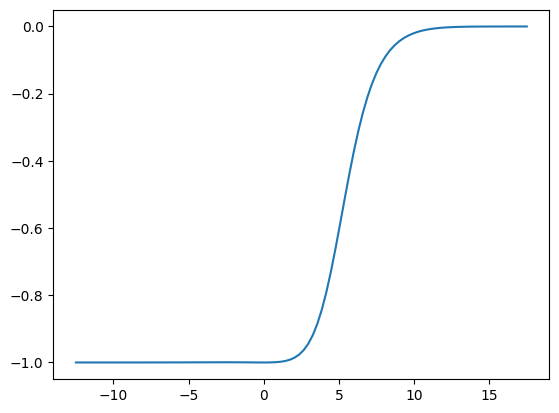

2026-06-22 09:43:58 | elapsed time: 0.499 s


In [ ]:
tPlot = np.linspace(tin, tout, 100)
yPlot = Aexp(tPlot, 0,0,0)

plt.plot(tPlot, yPlot)

# Gullstrand-Painleve

${\rm ds}^2={\rm dt}^2-({\rm dx}-v{\rm dt})^2$

$-\partial_t\psi=\left(\frac{1}{2}v_x+(v+\alpha^1)\partial_x+i\beta\right)\psi$

In [ ]:
xDim=1

a0 = 2
b0 = 1
#omega = sp.Rational(1,3)
omega = sp.Rational(1,4)
kappa = b0*omega

#v_sym = -a0*sp.exp(-(omega*t_sym)**2-(kappa*x_sym)**2)
#v_sym = -(sp.erf((kappa*x_sym+10)/3)-sp.erf(kappa*x_sym))*sp.exp(-(omega*t_sym)**2)
v_sym = -(sp.erf((kappa*x_sym+10)/4)-sp.erf(kappa*x_sym))*sp.exp(-(omega*t_sym)**2)

vx2_sym = sp.Rational(1,2) * sp.diff(v_sym, x_sym)

v = sp.lambdify((t_sym,x_sym,y_sym,z_sym), v_sym, modules=my_modules)
vx2 = sp.lambdify((t_sym,x_sym,y_sym,z_sym), vx2_sym, modules=my_modules)

2026-05-12 16:56:27 | elapsed time: 0.010 s


In [ ]:
xb=30/float(kappa)
tin=-4/float(omega); tout=4/float(omega)
dx0=.02/float(kappa); dk0=.02; kMax0=30;

dx0=np.min(np.array([dx0,np.pi/kMax0]))
nx=np.ceil(1+2*xb/dx0).astype(int)
nk=np.ceil(2*np.pi/(dk0*dx0)).astype(int)

nPad=np.maximum((nk-nx+1)//2,0)
nk=nx+2*nPad

2026-05-12 16:56:29 | elapsed time: 0.005 s


In [ ]:
[nx,nk]

[Array(3001, dtype=int64), Array(3927, dtype=int64)]

2026-05-12 16:56:31 | elapsed time: 0.003 s


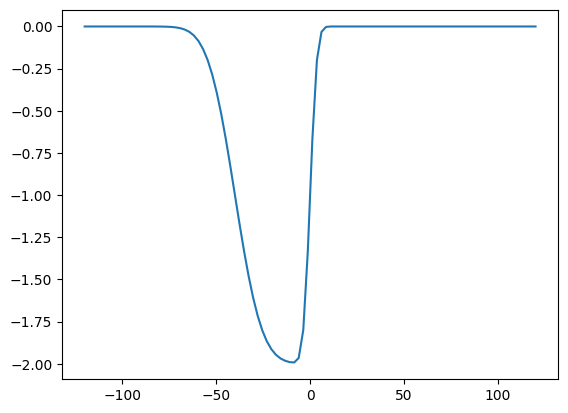

2026-05-12 16:56:34 | elapsed time: 0.119 s


In [ ]:
xPlot = np.linspace(-xb, xb, 100)
yPlot = v(0.0, xPlot,0,0)

plt.plot(xPlot, yPlot)

# 2D spinors

In [ ]:
#2D
gDim=2

alpha1=np.array([[0,1],[1,0]])
alpha2=np.array([[0,-1j],[1j,0]])
alpha3=np.array([[0,0],[0,0]])
beta=np.array([[1,0],[0,-1]])
id=np.array([[1,0],[0,1]])


def uSpin(P1,P2,P3,s):
    P0 = np.sqrt(1 + P1**2)
    u0 = (1 + P0) / np.sqrt(2 * P0 * (1 + P0))
    u1 = -P1 / np.sqrt(2 * P0 * (1 + P0))
    return np.stack([u0, u1], axis=-1)   # shape (..., 2)


def vSpin(P1,P2,P3,s):
    P0 = np.sqrt(1 + P1**2)
    v1 = (1 + P0) / np.sqrt(2 * P0 * (1 + P0))
    v0 = -P1 / np.sqrt(2 * P0 * (1 + P0))
    return np.stack([v0, v1], axis=-1)   # shape (..., 2)

2026-06-22 09:44:35 | elapsed time: 0.030 s


# Grid define

In [ ]:
x0=-xb; x1=xb; dx=(x1-x0)/(nx-1)
xGrid=np.linspace(x0,x1,nx)
dk=2*np.pi/(nk*dx); kMax=dk*(nk-1)/2
kGrid=2*np.pi*np.fft.fftfreq(nk,dx)

nPad=(nk-nx)//2
unPad=tuple(slice(nPad or None,-nPad or None) for _ in range(xDim))

psiOut=np.zeros(2*gDim*(nx**xDim),dtype=realType)

if xDim==1:
  X=xGrid; Y=0; Z=0;
  K1=kGrid; K2=0; K3=0;
elif xDim==2:
  X,Y=np.meshgrid(xGrid,xGrid,indexing='ij',sparse=True)
  Z=0
  K1,K2=np.meshgrid(kGrid,kGrid,indexing='ij',sparse=True)
  K3=0
elif xDim==3:
  X,Y,Z=np.meshgrid(xGrid,xGrid,xGrid,indexing='ij',sparse=True)
  K1,K2,K3=np.meshgrid(kGrid,kGrid,kGrid,indexing='ij',sparse=True)

Ushape=[gDim]+xDim*[nx]

pre1D=2/((2*np.pi)**4)
pre2D=2/((2*np.pi)**5)
pre3D=2/((2*np.pi)**6)

2026-06-22 09:45:07 | elapsed time: 0.645 s


In [ ]:
uGrid=np.conjugate(uSpin(kGrid,0,0,1))
vGrid=np.conjugate(vSpin(-kGrid,0,0,1))

2026-06-22 09:45:07 | elapsed time: 0.318 s


$x[j]=x_0+jdx$, $j=0,...,n_x-1$ and $dx=\frac{x_1-x_0}{n_x-1}$

After padding with $n_p=\frac{n_k-n_x}{2}$ zeros on all sides:
$x[j]=x_{\rm min}+jdx$, $j=0,...,n_k-1$, where $x_{\rm min}=\frac{n_k-1}{n_x-1}x_0$


unshifted: $k[l]=l dk$, $l=0,...,n_k-1$ and $dk=\frac{2\pi}{n_kdx}$

shifted, odd $n_k$: $l=-\frac{n_k-1}{2},...,\frac{n_k-1}{2} \quad\to\quad -k_{\rm min}=k_{\rm max}=dk\frac{n_k-1}{2}$

$k=k_1$

$f(k)=\int{\rm d}x\,f(x)e^{ikx}=dx e^{ikx_{\rm min}}\sum_{j=0}^{n_k-1}\exp(i* jdx* k)f(x_j)=dx e^{ikx_{\rm min}}{\rm ifft}(f,\text{norm="forward"})$

$f(x)=\int\frac{{\rm d}k}{2\pi}f(k)e^{-ikx}=\frac{{\rm d}k}{2\pi}\sum_{l=0}^{n_k-1}e^{-ik_l(x-x_{\rm min})}e^{-ik_lx_{\rm min}}f(k_l)=\frac{{\rm d}k}{2\pi}{\rm fft}(e^{-ikx_{\rm min}}f(k))$

In [ ]:
xMin=x0*(nk-1)/(nx-1)

@jax.jit
def fourierXtoK(f_x):
  f_k=np.pad(f_x,nPad)
  f_k=np.fft.ifftn(f_k,norm="forward")
  return (dx**xDim)*np.exp(1j*(K1+K2+K3)*xMin)*f_k

@jax.jit
def fourierKtoX(f_k):
  f_x=np.exp(-1j*(K1+K2+K3)*xMin)*f_k
  f_x=((dk/(2*np.pi))**xDim)*np.fft.fftn(f_x)
  return f_x[unPad]

2026-06-22 09:45:07 | elapsed time: 0.003 s


In [ ]:
kShift=np.fft.fftshift(kGrid)

2026-06-22 09:45:07 | elapsed time: 0.038 s


In [ ]:
def cubic_interp_1d(x_new, x_min, dx, val_grid):
    # scaled coordinate, integer index, fractional offset t
    x_scale = (x_new - x_min) / dx
    x_index = np.floor(x_scale).astype(int)
    t   = x_scale - x_index

    # cubic weights (shape (..., 4))
    weights = np.stack([
            (-2*t + 3*t**2 - t**3) / 6,
            ( 2 - t - 2*t**2 + t**3) / 2,
            ( 2*t + t**2 - t**3) / 2,
            (-t + t**3) / 6
        ], axis=-1)

    # stencil indices (i-1, i, i+1, i+2), clamped
    stencil = np.stack([
        x_index - 1,
        x_index,
        x_index + 1,
        x_index + 2
    ], axis=-1)

    stencil = np.clip(stencil, 0, val_grid.shape[0] - 1)

    vals = val_grid[stencil]          # shape (..., 4)
    return np.sum(weights * vals, axis=-1)

2026-06-22 09:45:07 | elapsed time: 0.001 s


# Inflation: diff eq and projection

xOut_x $=\hat{x}(x)$ with $x=$ xGrid for solving Dirac equation.

x_xIn $=x(\check{x})$ and xOut_xIn $=\hat{x}(\check{x})$ with $\check{x}=$ xGrid, for projecting the solutions.

In [ ]:
from scipy.integrate import solve_ivp

def solve_ivp_mid(fun, grid, y0=0.0, **opts):
    mid = grid.size // 2
    #t_mid = grid[mid]
    t_mid = 0

    # forward
    up = solve_ivp(
        fun, (t_mid, grid[-1]), [y0],
        t_eval=grid[mid:], **opts
    ).y[0]

    # backward
    down = solve_ivp(
        fun, (t_mid, grid[0]), [y0],
        t_eval=grid[:mid][::-1], **opts
    ).y[0][::-1]

    return np.concatenate([down, up])

2026-06-22 09:49:13 | elapsed time: 0.001 s


In [ ]:
x_xIn     = solve_ivp_mid(lambda y, x: 1/hIn(x), xGrid, rtol=1e-7, atol=1e-10)
xOut_xIn  = solve_ivp_mid(lambda x, y: hOut(x), x_xIn, rtol=1e-7, atol=1e-10)
xOut_x    = solve_ivp_mid(lambda x, y: hOut(x), xGrid, rtol=1e-7, atol=1e-10)

2026-06-22 09:49:13 | elapsed time: 0.485 s


In [ ]:
PplusInt, err = quad(lambda x: hIn(x)-hOut(x), 0, 50)
PminusInt, err = quad(lambda x: hIn(x)-hOut(x), 0, -50)

2026-06-22 09:49:14 | elapsed time: 0.223 s


The spatial derivatives, $\partial_i$, are calculated by Fourier transforming, multiplying by $k_i$, and then Fourier transforming back to $x^i$.
dPsi gives the right-hand side of the Dirac equation for the scattered wave, $\partial_t\psi_\text{scat.}=dPsi$.

$-\partial_0\psi=\left(\frac{1}{2}\partial_t A+\alpha^1 e^{-A}\partial_1+i\beta\right)\psi\qquad$
$G_0=\frac{1}{2}\partial_t A\qquad G_1=e^{-A} \qquad \alpha_1=\gamma^0\gamma^1 \qquad \beta=\gamma^0$

In [ ]:
# the ODE solver treats psi_scat as a flattened array, with real and imaginary parts stored separately
# yShape=[2,gDim,nx], [2,gDim,nx,nx] or [2,gDim,nx,nx,nx]

yShape=[2,gDim]+xDim*[nx]

def makeDer(P1,P2,P3,spin,sign):
  P0=np.sqrt(1+P1*P1+P2*P2+P3*P3)

  if sign==1:
    uOut=uSpin(P1,P2,P3,spin)
  elif sign==-1:
    uOut=vSpin(P1,P2,P3,spin)

  @jax.jit
  def dPsi(t,y,args):
    y=y.reshape(yShape)
    dy = [np.zeros(xDim*[nx],dtype=compType) for _ in range(gDim)]
    G0ar=chop(G0(t,X,Y,Z))
    G1ar=chop(G1(t,X,Y,Z))
    G1arBack=chop(G1ar/G1(tout,X,Y,Z)-1)

    for b in range(gDim):
      psiScat=y[0,b]+1j*y[1,b]
      psiBack=uOut[b]*np.exp(-1j*sign*(P0*t+P1*xOut_x))
      dy[b]=dy[b]+G0ar*(psiScat+psiBack)
      der=np.pad(psiScat,nPad)
      der=np.fft.fftn(der)
      for a in range(gDim):
        dera=np.fft.ifftn(1j*alpha1[a,b]*K1*der)[unPad]
        dy[a]=dy[a]+1j*beta[a,b]*psiScat+G1ar*dera
        dy[a]=dy[a]-1j*sign*P1*alpha1[a,b]*G1arBack*psiBack

    for a in range(gDim):
      dy[a]=-chop(dy[a])

    dy=np.concatenate(dy)
    return np.concatenate([np.real(dy),np.imag(dy)]).ravel()

  return dPsi

2026-06-22 09:49:14 | elapsed time: 0.002 s


The solutions to the Dirac equation are given by arrays for U_scat and V_scat on x=xGrid, but for the projections we need them on $\check{x}=$ xGrid, so we need to interpolate.

2026-06-22 09:49:14 | elapsed time: 0.006 s


2026-06-22 09:49:14 | elapsed time: 0.009 s


In [ ]:
solver = Dopri5()
controller = PIDController(rtol=1e-5, atol=1e-10)

@jax.jit
def method1(p1,q1):
  p2=0; p3=0; q2=0; q3=0; uspin=1; vspin=1
  up=uSpin(p1,p2,p3,uspin)
  vq=vSpin(q1,q2,q3,vspin)

  UdPsi=makeDer(p1,p2,p3,uspin,1)
  term=ODETerm(UdPsi)
  Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rUscat,iUscat=np.split(Uscat.ys[0],2)
  Uscat=rUscat+1j*iUscat
  Uscat=Uscat.reshape(Ushape)

  VdPsi=makeDer(q1,q2,q3,vspin,-1)
  term=ODETerm(VdPsi)
  Vscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rVscat,iVscat=np.split(Vscat.ys[0],2)
  Vscat=rVscat+1j*iVscat
  Vscat=Vscat.reshape(Ushape)

  p0=np.sqrt(1+p1**2+p2**2+p3**2)
  q0=np.sqrt(1+q1**2+q2**2+q3**2)

  k0=np.sqrt(1+kGrid**2)

  # project U_out

  Jf=p1*(1-hOut(x_xIn)/hIn(x_xIn))*np.exp(-1j*p0*tin-1j*p1*xOut_xIn)
  Jf=fourierXtoK(Jf)

  Y1f=cubic_interp_1d(x_xIn,x0,dx,Uscat[0])
  Y1f=fourierXtoK(Y1f)

  Y2f=cubic_interp_1d(x_xIn,x0,dx,Uscat[1])
  Y2f=fourierXtoK(Y2f)

  denom = kGrid - p1
  safe_denom = np.where(denom == 0, 1, denom)

  num = np.einsum("ia,a->i",vGrid,up)
  JpreVU = np.where(denom == 0, 1/(2*(1+p1**2)), num / safe_denom)
  JpreUU = np.einsum("ia,a->i",uGrid,up)

  VinUoutTab=np.exp(-1j*k0*tin)*(vGrid[:,0]*Y1f+vGrid[:,1]*Y2f-JpreVU*Jf)
  UinUoutTab=np.exp(1j*k0*tin)*(denom*(uGrid[:,0]*Y1f+uGrid[:,1]*Y2f)-JpreUU*Jf)

  # project V_out

  Jf=-q1*(1-hOut(x_xIn)/hIn(x_xIn))*np.exp(1j*q0*tin+1j*q1*xOut_xIn)
  Jf=fourierXtoK(Jf)

  Y1f=cubic_interp_1d(x_xIn,x0,dx,Vscat[0])
  Y1f=fourierXtoK(Y1f)

  Y2f=cubic_interp_1d(x_xIn,x0,dx,Vscat[1])
  Y2f=fourierXtoK(Y2f)

  denom = kGrid + q1
  safe_denom = np.where(denom == 0, 1, denom)

  num = np.einsum("ia,a->i",uGrid,vq)
  JpreUV = np.where(denom == 0, -1/(2*(1+q1**2)), num / safe_denom)
  JpreVV = np.einsum("ia,a->i",vGrid,vq)

  UinVoutTab=np.exp(1j*k0*tin)*(uGrid[:,0]*Y1f+uGrid[:,1]*Y2f-JpreUV*Jf)
  VinVoutTab=np.exp(-1j*k0*tin)*(denom*(vGrid[:,0]*Y1f+vGrid[:,1]*Y2f)-JpreVV*Jf)


  # UVVV

  grand = np.conjugate(VinUoutTab)*VinVoutTab
  grand = np.fft.fftshift(grand)
  grand1 = cubic_interp_1d(-q1+kGrid, kShift[0], dk, grand)
  grand2 = cubic_interp_1d(-q1-kGrid, kShift[0], dk, grand)
  grand = grand1-grand2
  denom = kGrid
  safe_denom = np.where(denom == 0, 1, denom)
  grand = grand/safe_denom

  fixAt0 = (4/3)*grand[1]-(1/3)*grand[2]
  grand = grand.at[0].set(fixAt0)
  grand = np.fft.fftshift(grand)

  UVVVpv = simpson_jax(grand,dk/(4*np.pi))

  UVVVdelta = np.conjugate(VinUoutTab)
  UVVVdelta = np.fft.fftshift(UVVVdelta)
  UVVVdelta = cubic_interp_1d(-q1, kShift[0], dk, UVVVdelta)
  UVVVdelta = UVVVdelta*(np.exp(-1j*q1*PplusInt)+np.exp(-1j*q1*PminusInt))/2

  UVVV = UVVVpv+UVVVdelta


  # UUUV

  grand = np.conjugate(UinUoutTab)*UinVoutTab
  grand = np.fft.fftshift(grand)
  grand1 = cubic_interp_1d(p1+kGrid, kShift[0], dk, grand)
  grand2 = cubic_interp_1d(p1-kGrid, kShift[0], dk, grand)
  grand = grand1-grand2
  denom = kGrid
  safe_denom = np.where(denom == 0, 1, denom)
  grand = grand/safe_denom

  fixAt0 = (4/3)*grand[1]-(1/3)*grand[2]
  grand = grand.at[0].set(fixAt0)
  grand = np.fft.fftshift(grand)

  UUUVpv = simpson_jax(grand,dk/(4*np.pi))

  UUUVdelta = UinVoutTab
  UUUVdelta = np.fft.fftshift(UUUVdelta)
  UUUVdelta = cubic_interp_1d(p1, kShift[0], dk, UUUVdelta)
  UUUVdelta = UUUVdelta*(np.exp(1j*p1*PplusInt)+np.exp(1j*p1*PminusInt))/2

  UUUV = UUUVpv+UUUVdelta


  return np.sqrt(pre1D)*np.array([UUUV,-UVVV])

2026-06-22 09:49:14 | elapsed time: 0.005 s


2026-06-22 09:49:14 | elapsed time: 0.008 s


2026-06-22 09:49:14 | elapsed time: 0.011 s


In [ ]:
solver = Dopri5()
controller = PIDController(rtol=1e-5, atol=1e-10)

@jax.jit
def method2(p1,q1):
  p2=0; p3=0; q2=0; q3=0; uspin=1; vspin=1
  up=uSpin(p1,p2,p3,uspin)
  vq=vSpin(q1,q2,q3,vspin)

  UdPsi=makeDer(p1,p2,p3,uspin,1)
  term=ODETerm(UdPsi)
  Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rUscat,iUscat=np.split(Uscat.ys[0],2)
  Uscat=rUscat+1j*iUscat
  Uscat=Uscat.reshape(Ushape)

  VdPsi=makeDer(q1,q2,q3,vspin,-1)
  term=ODETerm(VdPsi)
  Vscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rVscat,iVscat=np.split(Vscat.ys[0],2)
  Vscat=rVscat+1j*iVscat
  Vscat=Vscat.reshape(Ushape)

  p0=np.sqrt(1+p1**2+p2**2+p3**2)
  q0=np.sqrt(1+q1**2+q2**2+q3**2)

  # project U_back

  J1=np.exp(-1j*p0*tin-1j*p1*xOut_xIn)
  J2=(hOut(x_xIn)/hIn(x_xIn)-1)*np.exp(-1j*p0*tin-1j*p1*xOut_xIn)
  J2=fourierXtoK(J2)

  denom = kGrid - p1
  safe_denom = np.where(denom == 0, 1, denom)

  num = np.einsum("ia,a->i",uGrid,up)
  num = p1*(num-1)
  UinUback = np.where(denom == 0, 0, num / safe_denom)
  UinUback = UinUback*J2
  UinUback = J1 + fourierKtoX(UinUback)

  num = p1 * np.einsum("ia,a->i",vGrid,up)
  VinUback = np.where(denom == 0, p1/(2*(1+p1**2)), num / safe_denom)
  VinUback = VinUback*J2
  VinUback = fourierKtoX(VinUback)


  # project V_back

  J1=np.exp(1j*q0*tin+1j*q1*xOut_xIn)
  J2=(hOut(x_xIn)/hIn(x_xIn)-1)*np.exp(1j*q0*tin+1j*q1*xOut_xIn)
  J2=fourierXtoK(J2)

  denom = kGrid + q1
  safe_denom = np.where(denom == 0, 1, denom)

  num = np.einsum("ia,a->i",vGrid,vq)
  num =-q1*(num-1)
  VinVback = np.where(denom == 0, 0, num / safe_denom)
  VinVback = VinVback*J2
  VinVback = J1 + fourierKtoX(VinVback)

  num = -q1 * np.einsum("ia,a->i",uGrid,vq)
  UinVback = np.where(denom == 0, q1/(2*(1+q1**2)), num / safe_denom)
  UinVback = UinVback*J2
  UinVback = fourierKtoX(UinVback)


  # project U_scat

  Y1f=cubic_interp_1d(x_xIn, x0, dx, Uscat[0])
  Y1f=fourierXtoK(Y1f)

  Y2f=cubic_interp_1d(x_xIn, x0, dx, Uscat[1])
  Y2f=fourierXtoK(Y2f)

  UinUscat=uGrid[:,0]*Y1f+uGrid[:,1]*Y2f
  UinUscat=fourierKtoX(UinUscat)

  VinUscat=vGrid[:,0]*Y1f+vGrid[:,1]*Y2f
  VinUscat=fourierKtoX(VinUscat)


  # project V_scat

  Y1f=cubic_interp_1d(x_xIn, x0, dx, Vscat[0])
  Y1f=fourierXtoK(Y1f)

  Y2f=cubic_interp_1d(x_xIn, x0, dx, Vscat[1])
  Y2f=fourierXtoK(Y2f)

  UinVscat=uGrid[:,0]*Y1f+uGrid[:,1]*Y2f
  UinVscat=fourierKtoX(UinVscat)

  VinVscat=vGrid[:,0]*Y1f+vGrid[:,1]*Y2f
  VinVscat=fourierKtoX(VinVscat)


  # int dx f*(x)g(x)

  UinGrand=np.conjugate(UinUback+UinUscat)*(UinVback+UinVscat)
  UinFin=np.sqrt(pre1D)*simpson_jax(UinGrand,dx)

  VinGrand=np.conjugate(VinUback+VinUscat)*(VinVback+VinVscat)
  VinFin=-np.sqrt(pre1D)*simpson_jax(VinGrand,dx)

  return np.array([UinFin, VinFin])

2026-06-22 09:49:14 | elapsed time: 0.003 s


2026-06-22 09:49:14 | elapsed time: 0.006 s


# Gullstrand-Painleve: diff eq and projection

In [ ]:
# the ODE solver treats psi_scat as a flattened array, with real and imaginary parts stored separately
# yShape=[2,gDim,nx], [2,gDim,nx,nx] or [2,gDim,nx,nx,nx]

yShape=[2,gDim]+xDim*[nx]

def makeDer(P1,P2,P3,spin,sign):
  P0=np.sqrt(1+P1*P1+P2*P2+P3*P3)

  if sign==1:
    uOut=uSpin(P1,P2,P3,spin)
  elif sign==-1:
    uOut=vSpin(P1,P2,P3,spin)

  @jax.jit
  def dPsi(t,y,args):
    y=y.reshape(yShape)
    dy = [np.zeros(xDim*[nx],dtype=compType) for _ in range(gDim)]
    vx2ar=chop(vx2(t,X,Y,Z))
    vAr=chop(v(t,X,Y,Z))

    for b in range(gDim):
      psiScat=y[0,b]+1j*y[1,b]
      psiBack=uOut[b]*np.exp(-1j*sign*(P0*t+P1*X))
      dy[b]=dy[b]+vx2ar*(psiScat+psiBack)-1j*sign*P1*vAr*psiBack
      der=np.pad(psiScat,nPad)
      der=np.fft.fftn(der)
      der=np.fft.ifftn(1j*K1*der)[unPad]
      dy[b]=dy[b]+vAr*der
      for a in range(gDim):
        dy[a]=dy[a]+1j*beta[a,b]*psiScat+alpha1[a,b]*der

    for a in range(gDim):
      dy[a]=-chop(dy[a])

    dy=np.concatenate(dy)
    return np.concatenate([np.real(dy),np.imag(dy)]).ravel()

  return dPsi

2026-05-12 16:56:44 | elapsed time: 0.002 s


2026-05-12 16:56:44 | elapsed time: 0.006 s


In [ ]:
solver = Dopri5()
controller = PIDController(rtol=1e-5, atol=1e-10)

@jax.jit
def method1(p1,q1):
  p2=0; p3=0; q2=0; q3=0; uspin=1; vspin=1
  # up=uSpin(p1,p2,p3,uspin)
  # vq=vSpin(q1,q2,q3,vspin)

  UdPsi=makeDer(p1,p2,p3,uspin,1)
  term=ODETerm(UdPsi)
  Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rUscat,iUscat=np.split(Uscat.ys[0],2)
  Uscat=rUscat+1j*iUscat
  Uscat=Uscat.reshape(Ushape)

  VdPsi=makeDer(q1,q2,q3,vspin,-1)
  term=ODETerm(VdPsi)
  Vscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rVscat,iVscat=np.split(Vscat.ys[0],2)
  Vscat=rVscat+1j*iVscat
  Vscat=Vscat.reshape(Ushape)

  # p0=np.sqrt(1+p1**2+p2**2+p3**2)
  # q0=np.sqrt(1+q1**2+q2**2+q3**2)

  k0=np.sqrt(1+kGrid**2)

  # project U_out

  # Jf=p1*(1-hOut(x_xIn)/hIn(x_xIn))*np.exp(-1j*p0*tin-1j*p1*xOut_xIn)
  # Jf=fourierXtoK(Jf)

  # Y1f=cubic_interp_1d(x_xIn,x0,dx,Uscat[0])
  # Y1f=fourierXtoK(Y1f)
  Y1f=fourierXtoK(Uscat[0])

  # Y2f=cubic_interp_1d(x_xIn,x0,dx,Uscat[1])
  # Y2f=fourierXtoK(Y2f)
  Y2f=fourierXtoK(Uscat[1])

  denom = kGrid - p1
  # safe_denom = np.where(denom == 0, 1, denom)

  # num = np.einsum("ia,a->i",vGrid,up)
  # JpreVU = np.where(denom == 0, 1/(2*(1+p1**2)), num / safe_denom)
  # JpreUU = np.einsum("ia,a->i",uGrid,up)

  # VinUoutTab=np.exp(-1j*k0*tin)*(vGrid[:,0]*Y1f+vGrid[:,1]*Y2f-JpreVU*Jf)
  # UinUoutTab=np.exp(1j*k0*tin)*(denom*(uGrid[:,0]*Y1f+uGrid[:,1]*Y2f)-JpreUU*Jf)

  VinUoutTab=np.exp(-1j*k0*tin)*(vGrid[:,0]*Y1f+vGrid[:,1]*Y2f)
  UinUoutTab=np.exp(1j*k0*tin)*(denom*(uGrid[:,0]*Y1f+uGrid[:,1]*Y2f))

  # project V_out

  # Jf=-q1*(1-hOut(x_xIn)/hIn(x_xIn))*np.exp(1j*q0*tin+1j*q1*xOut_xIn)
  # Jf=fourierXtoK(Jf)

  # Y1f=cubic_interp_1d(x_xIn,x0,dx,Vscat[0])
  # Y1f=fourierXtoK(Y1f)

  # Y2f=cubic_interp_1d(x_xIn,x0,dx,Vscat[1])
  # Y2f=fourierXtoK(Y2f)

  Y1f=fourierXtoK(Vscat[0])
  Y2f=fourierXtoK(Vscat[1])

  denom = kGrid + q1
  # safe_denom = np.where(denom == 0, 1, denom)

  # num = np.einsum("ia,a->i",uGrid,vq)
  # JpreUV = np.where(denom == 0, -1/(2*(1+q1**2)), num / safe_denom)
  # JpreVV = np.einsum("ia,a->i",vGrid,vq)

  # UinVoutTab=np.exp(1j*k0*tin)*(uGrid[:,0]*Y1f+uGrid[:,1]*Y2f-JpreUV*Jf)
  # VinVoutTab=np.exp(-1j*k0*tin)*(denom*(vGrid[:,0]*Y1f+vGrid[:,1]*Y2f)-JpreVV*Jf)

  UinVoutTab=np.exp(1j*k0*tin)*(uGrid[:,0]*Y1f+uGrid[:,1]*Y2f)
  VinVoutTab=np.exp(-1j*k0*tin)*(denom*(vGrid[:,0]*Y1f+vGrid[:,1]*Y2f))


  # UVVV

  grand = np.conjugate(VinUoutTab)*VinVoutTab
  grand = np.fft.fftshift(grand)
  grand1 = cubic_interp_1d(-q1+kGrid, kShift[0], dk, grand)
  grand2 = cubic_interp_1d(-q1-kGrid, kShift[0], dk, grand)
  grand = grand1-grand2
  denom = kGrid
  safe_denom = np.where(denom == 0, 1, denom)
  grand = grand/safe_denom

  fixAt0 = (4/3)*grand[1]-(1/3)*grand[2]
  grand = grand.at[0].set(fixAt0)
  grand = np.fft.fftshift(grand)

  UVVVpv = simpson_jax(grand,dk/(4*np.pi))

  UVVVdelta = np.conjugate(VinUoutTab)
  UVVVdelta = np.fft.fftshift(UVVVdelta)
  UVVVdelta = cubic_interp_1d(-q1, kShift[0], dk, UVVVdelta)
  # UVVVdelta = UVVVdelta*(np.exp(-1j*q1*PplusInt)+np.exp(-1j*q1*PminusInt))/2

  UVVV = UVVVpv+UVVVdelta


  # UUUV

  grand = np.conjugate(UinUoutTab)*UinVoutTab
  grand = np.fft.fftshift(grand)
  grand1 = cubic_interp_1d(p1+kGrid, kShift[0], dk, grand)
  grand2 = cubic_interp_1d(p1-kGrid, kShift[0], dk, grand)
  grand = grand1-grand2
  denom = kGrid
  safe_denom = np.where(denom == 0, 1, denom)
  grand = grand/safe_denom

  fixAt0 = (4/3)*grand[1]-(1/3)*grand[2]
  grand = grand.at[0].set(fixAt0)
  grand = np.fft.fftshift(grand)

  UUUVpv = simpson_jax(grand,dk/(4*np.pi))

  UUUVdelta = UinVoutTab
  UUUVdelta = np.fft.fftshift(UUUVdelta)
  UUUVdelta = cubic_interp_1d(p1, kShift[0], dk, UUUVdelta)
  # UUUVdelta = UUUVdelta*(np.exp(1j*p1*PplusInt)+np.exp(1j*p1*PminusInt))/2

  UUUV = UUUVpv+UUUVdelta


  return np.sqrt(pre1D)*np.array([UUUV,-UVVV])

2026-05-12 16:56:44 | elapsed time: 0.019 s


2026-05-12 16:56:44 | elapsed time: 0.023 s


2026-05-12 16:56:44 | elapsed time: 0.026 s


In [ ]:
solver = Dopri5()
controller = PIDController(rtol=1e-5, atol=1e-10)

@jax.jit
def method2(p1,q1):
  p2=0; p3=0; q2=0; q3=0; uspin=1; vspin=1
  # up=uSpin(p1,p2,p3,uspin)
  # vq=vSpin(q1,q2,q3,vspin)

  UdPsi=makeDer(p1,p2,p3,uspin,1)
  term=ODETerm(UdPsi)
  Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rUscat,iUscat=np.split(Uscat.ys[0],2)
  Uscat=rUscat+1j*iUscat
  Uscat=Uscat.reshape(Ushape)

  VdPsi=makeDer(q1,q2,q3,vspin,-1)
  term=ODETerm(VdPsi)
  Vscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

  rVscat,iVscat=np.split(Vscat.ys[0],2)
  Vscat=rVscat+1j*iVscat
  Vscat=Vscat.reshape(Ushape)

  p0=np.sqrt(1+p1**2+p2**2+p3**2)
  q0=np.sqrt(1+q1**2+q2**2+q3**2)

  # project U_back

  # J1=np.exp(-1j*p0*tin-1j*p1*xOut_xIn)
  # J2=(hOut(x_xIn)/hIn(x_xIn)-1)*np.exp(-1j*p0*tin-1j*p1*xOut_xIn)
  # J2=fourierXtoK(J2)

  # denom = kGrid - p1
  # safe_denom = np.where(denom == 0, 1, denom)

  # num = np.einsum("ia,a->i",uGrid,up)
  # num = p1*(num-1)
  # UinUback = np.where(denom == 0, 0, num / safe_denom)
  # UinUback = UinUback*J2
  # UinUback = J1 + fourierKtoX(UinUback)

  J1=np.exp(-1j*p0*tin-1j*p1*X)
  UinUback = J1

  # num = p1 * np.einsum("ia,a->i",vGrid,up)
  # VinUback = np.where(denom == 0, p1/(2*(1+p1**2)), num / safe_denom)
  # VinUback = VinUback*J2
  # VinUback = fourierKtoX(VinUback)

  VinUback = 0

  # project V_back

  # J1=np.exp(1j*q0*tin+1j*q1*xOut_xIn)
  # J2=(hOut(x_xIn)/hIn(x_xIn)-1)*np.exp(1j*q0*tin+1j*q1*xOut_xIn)
  # J2=fourierXtoK(J2)

  # denom = kGrid + q1
  # safe_denom = np.where(denom == 0, 1, denom)

  # num = np.einsum("ia,a->i",vGrid,vq)
  # num =-q1*(num-1)
  # VinVback = np.where(denom == 0, 0, num / safe_denom)
  # VinVback = VinVback*J2
  # VinVback = J1 + fourierKtoX(VinVback)

  J1=np.exp(1j*q0*tin+1j*q1*X)
  VinVback = J1

  # num = -q1 * np.einsum("ia,a->i",uGrid,vq)
  # UinVback = np.where(denom == 0, q1/(2*(1+q1**2)), num / safe_denom)
  # UinVback = UinVback*J2
  # UinVback = fourierKtoX(UinVback)

  UinVback = 0

  # project U_scat

  # Y1f=cubic_interp_1d(x_xIn, x0, dx, Uscat[0])
  # Y1f=fourierXtoK(Y1f)

  # Y2f=cubic_interp_1d(x_xIn, x0, dx, Uscat[1])
  # Y2f=fourierXtoK(Y2f)

  Y1f=fourierXtoK(Uscat[0])
  Y2f=fourierXtoK(Uscat[1])

  UinUscat=uGrid[:,0]*Y1f+uGrid[:,1]*Y2f
  UinUscat=fourierKtoX(UinUscat)

  VinUscat=vGrid[:,0]*Y1f+vGrid[:,1]*Y2f
  VinUscat=fourierKtoX(VinUscat)


  # project V_scat

  # Y1f=cubic_interp_1d(x_xIn, x0, dx, Vscat[0])
  # Y1f=fourierXtoK(Y1f)

  # Y2f=cubic_interp_1d(x_xIn, x0, dx, Vscat[1])
  # Y2f=fourierXtoK(Y2f)

  Y1f=fourierXtoK(Vscat[0])
  Y2f=fourierXtoK(Vscat[1])

  UinVscat=uGrid[:,0]*Y1f+uGrid[:,1]*Y2f
  UinVscat=fourierKtoX(UinVscat)

  VinVscat=vGrid[:,0]*Y1f+vGrid[:,1]*Y2f
  VinVscat=fourierKtoX(VinVscat)


  # int dx f*(x)g(x)

  UinGrand=np.conjugate(UinUback+UinUscat)*(UinVback+UinVscat)
  UinFin=np.sqrt(pre1D)*simpson_jax(UinGrand,dx)

  VinGrand=np.conjugate(VinUback+VinUscat)*(VinVback+VinVscat)
  VinFin=-np.sqrt(pre1D)*simpson_jax(VinGrand,dx)

  return np.array([UinFin, VinFin])

2026-05-12 16:56:44 | elapsed time: 0.003 s


2026-05-12 16:56:44 | elapsed time: 0.006 s


2026-05-12 16:56:44 | elapsed time: 0.010 s


# Check definitions

In [ ]:
[float(kappa)*dx,dk,kMax,nPad]

[Array(0.02094241, dtype=float64, weak_type=True),
 Array(0.05000368, dtype=float64, weak_type=True),
 Array(29.977208, dtype=float64, weak_type=True),
 Array(122, dtype=int64)]

2026-06-22 09:49:35 | elapsed time: 0.039 s


In [ ]:
P1=.3; P2=0; P3=0; delta1=0; delta2=0; delta3=0

p1=-P1+delta1/2; p2=-P2+delta2/2; p3=-P3+delta3/2
q1=P1+delta1/2; q2=P2+delta2/2; q3=P3+delta3/2
#uSpin=2; vSpin=2

2026-06-22 09:50:16 | elapsed time: 0.001 s


In [ ]:
UdPsi=makeDer(p1,p2,p3,1,1)
term=ODETerm(UdPsi)
Uscat = diffeqsolve(term,solver,t0=tout,t1=tin,dt0=-1e-2,y0=psiOut,
    stepsize_controller=controller)

rUscat,iUscat=np.split(Uscat.ys[0],2)
Uscat=rUscat+1j*iUscat
Uscat=Uscat.reshape(Ushape)

2026-06-22 09:50:23 | elapsed time: 3.571 s


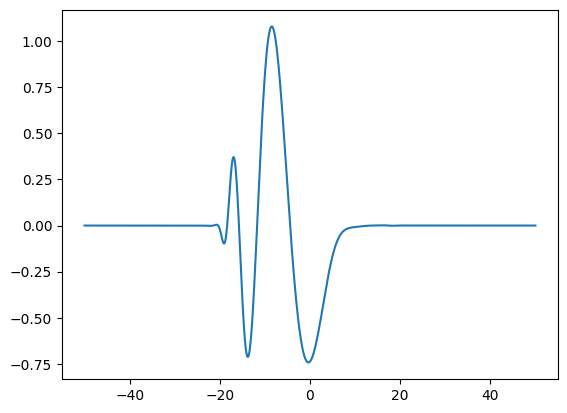

2026-06-22 09:50:27 | elapsed time: 0.205 s


In [ ]:
plt.plot(xGrid,np.real(Uscat[0]))

In [ ]:
[Uscat[0,0],Uscat[0,-1]]

[Array(-1.72734592e-08+8.93064753e-09j, dtype=complex128),
 Array(-5.09975799e-08-2.11636098e-08j, dtype=complex128)]

2026-06-22 09:50:31 | elapsed time: 0.059 s


In [ ]:
fin1=method1(p1,q1)

2026-06-22 09:50:47 | elapsed time: 5.427 s


In [ ]:
fin1

Array([-0.00060351-0.0006063j, -0.00060351-0.0006063j], dtype=complex128)

2026-06-22 09:50:49 | elapsed time: 0.002 s


In [ ]:
np.abs(fin1[0]/fin1[1]-1)

Array(5.89511195e-08, dtype=float64)

2026-06-22 09:50:54 | elapsed time: 0.200 s


In [ ]:
fin2=method2(p1,q1)

2026-06-22 09:51:00 | elapsed time: 5.020 s


In [ ]:
fin2

Array([-0.00060347-0.00060628j, -0.00060357-0.00060632j], dtype=complex128)

2026-06-22 09:51:02 | elapsed time: 0.002 s


In [ ]:
np.abs(fin1/fin2-1)

Array([5.56816482e-05, 6.92527522e-05], dtype=float64)

2026-06-22 09:51:06 | elapsed time: 0.160 s


In [ ]:
np.abs(fin2[0]/fin2[1]-1)

Array(0.00012493, dtype=float64)

2026-06-22 09:51:17 | elapsed time: 0.004 s


# 1+1

In [ ]:
pmin=-1.2; pmax=1.2; dp=(pmax-pmin)/100.
pList=np.arange(pmin,pmax+dp,dp)

2026-06-22 09:51:49 | elapsed time: 0.123 s


In [ ]:
batched = jax.jit(jax.vmap(lambda p: method1(p,-p)))
values1 = batched(pList)

2026-06-22 09:52:00 | elapsed time: 7.393 s


In [ ]:
batched = jax.jit(jax.vmap(lambda p: method2(p,-p)))
values2 = batched(pList)

2026-06-22 09:52:08 | elapsed time: 6.514 s


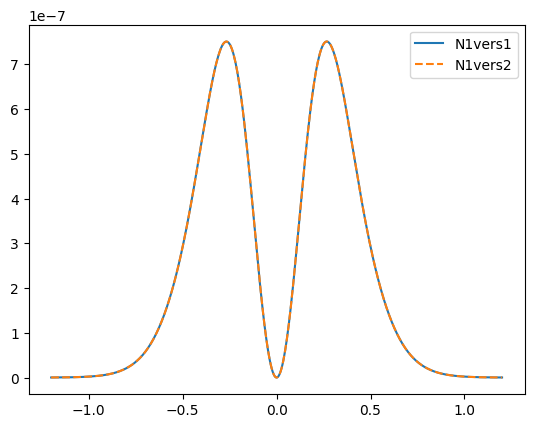

2026-06-22 09:52:12 | elapsed time: 0.489 s


In [ ]:
inter1=make_interp_spline(pList,np.abs(values1[:,0])**2, k=3)
inter2=make_interp_spline(pList,np.abs(values2[:,1])**2, k=3)

pDense=np.linspace(pList.min(), pList.max(), 500)
dense1=inter1(pDense)
dense2=inter2(pDense)

plt.plot(pDense,dense1,label='N1vers1')
plt.plot(pDense,dense2,label='N1vers2',linestyle="--")
plt.legend()
plt.show()

In [ ]:
toMathematica(np.stack([pList,np.abs(values1[:,0])**2], axis=1))

{{-1.2, 1.621426329502859*10^-10}, {-1.176, 2.2214507580766433*10^-10}, {-1.152, 3.0590099709666487*10^-10}, {-1.128, 4.1562125620018077*10^-10}, {-1.1039999999999999, 5.648197427184251*10^-10}, {-1.08, 7.704347001280099*10^-10}, {-1.056, 1.042063045736306*10^-09}, {-1.032, 1.411342436203711*10^-09}, {-1.008, 1.897521432156201*10^-09}, {-0.984, 2.5378500322331616*10^-09}, {-0.96, 3.383921589170121*10^-09}, {-0.9359999999999999, 4.497642759527833*10^-09}, {-0.9119999999999999, 5.958022502440492*10^-09}, {-0.8879999999999999, 7.864202067004953*10^-09}, {-0.8639999999999999, 1.031239093960188*10^-08}, {-0.84, 1.3477481616977538*10^-08}, {-0.816, 1.7500047196681285*10^-08}, {-0.7919999999999999, 2.2608531187878075*10^-08}, {-0.768, 2.9015058100209895*10^-08}, {-0.744, 3.708132633020343*10^-08}, {-0.72, 4.705757551025159*10^-08}, {-0.696, 5.932055359972726*10^-08}, {-0.6719999999999999, 7.42103950673012*10^-08}, {-0.6479999999999999, 9.206804545745157*10^-08}, {-0.6239999999999999, 1.132501

In [ ]:
.8+.6/2

1.1

2026-06-22 09:55:19 | elapsed time: 0.001 s


In [ ]:
pmin=-1.2; pmax=1.2; dp=(pmax-pmin)/100.
pList=np.arange(pmin,pmax+dp,dp)

def inner(p1):
    return jax.vmap(lambda q1: method1(-p1, -q1))(pList)

batched_2D = jax.jit(jax.vmap(inner))

N_values2D = batched_2D(pList)

2026-06-22 09:55:56 | elapsed time: 6.670 s


In [ ]:
N=np.abs(N_values2D[:,:,0])**2

2026-06-22 09:57:59 | elapsed time: 0.099 s


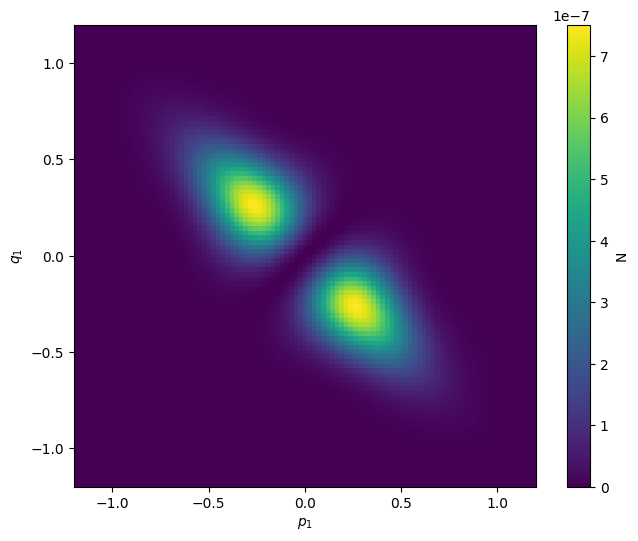

2026-06-22 09:58:06 | elapsed time: 0.458 s


In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(
    N.T,
    origin="lower",
    extent=[pList[0], pList[-1], pList[0], pList[-1]]
)
plt.colorbar(label="N")
plt.xlabel(r"$p_1$")
plt.ylabel(r"$q_1$")
plt.show()

In [ ]:
import matplotlib.colors as mcolors

colist = 3*[(0.54, 0.2, 0.14), (1.0, 0.38, 0.01),(1.0, 1.0, 0.6)]
cmap = mcolors.LinearSegmentedColormap.from_list( "myblend", colist)

2026-06-22 09:59:05 | elapsed time: 0.001 s


In [ ]:
from scipy.ndimage import zoom

N_fine = zoom(N, 4, order=3)

pList_fine = np.linspace(pList[0], pList[-1], N_fine.shape[0])

P_grid_fine = (pList_fine[None, :] - pList_fine[:, None]) / 2
Delta_grid_fine = pList_fine[:, None] + pList_fine[None, :]

2026-06-22 09:59:45 | elapsed time: 0.020 s


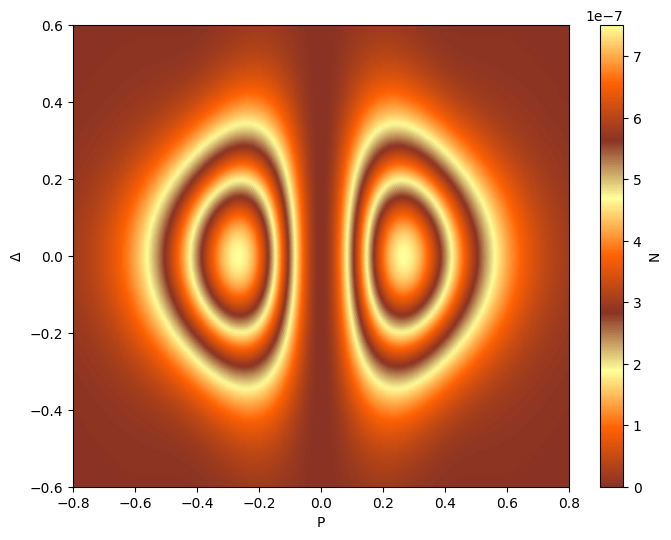

2026-06-22 10:00:10 | elapsed time: 0.971 s


In [ ]:
plt.figure(figsize=(8,6))
plt.pcolormesh(
    P_grid_fine,
    Delta_grid_fine,
    N_fine,
    shading="gouraud",
    cmap=cmap
)
plt.colorbar(label="N")
plt.xlabel("P")
plt.ylabel(r"$\Delta$")
plt.xlim(-.8,.8)
plt.ylim(-.6,.6)
plt.show()

In [ ]:
toMathematica(np.abs(N_values2D[:,:,0])**2)

{{2.1131429021713294*10^-14, 1.7609895137740655*10^-14, 9.609665699900816*10^-15, 4.254991209330448*10^-15, 1.9380399341196717*10^-15, 2.516997988135978*10^-15, 3.791636154292244*10^-16, 1.7059120032061145*10^-15, 1.6866267258561103*10^-15, 1.5632601716540142*10^-15, 3.279853232478287*10^-15, 7.282056836738496*10^-15, 1.3589585590412727*10^-14, 1.8785951069740897*10^-14, 2.3333137294395932*10^-14, 3.0909442220314636*10^-14, 3.0004774822528956*10^-14, 2.3514139922431946*10^-14, 4.903524586304544*10^-14, 2.8990179717578005*10^-14, 2.897059055387552*10^-14, 2.1631836367786826*10^-14, 3.651594698568857*10^-14, 3.688811897843083*10^-14, 2.934641697523723*10^-14, 2.1653243654752123*10^-14, 2.4742080584689357*10^-14, 2.935720933632258*10^-14, 3.017919061693287*10^-14, 3.6968323727991027*10^-14, 4.959444284239437*10^-14, 9.103743306124568*10^-14, 1.8039674623145316*10^-13, 1.6829101290154493*10^-13, 2.4597110999194617*10^-13, 4.75210634689605*10^-13, 6.257030231038222*10^-13, 7.790369126023349

In [ ]:
toMathematica(pList)

{-1.2, -1.176, -1.152, -1.128, -1.1039999999999999, -1.08, -1.056, -1.032, -1.008, -0.984, -0.96, -0.9359999999999999, -0.9119999999999999, -0.8879999999999999, -0.8639999999999999, -0.84, -0.816, -0.7919999999999999, -0.768, -0.744, -0.72, -0.696, -0.6719999999999999, -0.6479999999999999, -0.6239999999999999, -0.6, -0.576, -0.5519999999999999, -0.5279999999999999, -0.5039999999999999, -0.48, -0.45599999999999996, -0.43199999999999994, -0.4079999999999999, -0.3839999999999999, -0.36, -0.33599999999999997, -0.31199999999999994, -0.2879999999999999, -0.2639999999999999, -0.24, -0.21599999999999997, -0.19199999999999995, -0.16799999999999993, -0.1439999999999999, -0.11999999999999988, -0.09599999999999986, -0.07199999999999984, -0.04799999999999982, -0.02400000000000002, 0.0, 0.02400000000000002, 0.04800000000000004, 0.07200000000000006, 0.09600000000000009, 0.1200000000000001, 0.14400000000000013, 0.16800000000000015, 0.19200000000000017, 0.21599999999999997, 0.24, 0.264, 0.2880000000000